# Oil Trade Network 1988-2025

In [23]:
# Importing data

import pandas as pd
df1 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_3_17_2026_11_45_38.csv", encoding='latin-1', index_col=False)
df2 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_3_17_2026_11_47_10.csv", encoding='latin-1', index_col=False)
df3 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_3_17_2026_11_47_47.csv", encoding='latin-1', index_col=False)
df4 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_8_7_2026_15_16_57.csv", encoding='latin-1', index_col=False)
df_all = pd.concat([df1, df2, df3, df4])

In [37]:
# First we will sort the dataframes by year, then separate the imports from exports. 
# Sometimes, there is a discrepancy between the reported exports of one country and the reported imports of its trade partner.
# If both numbers are available, we will use the figure reported by the importer.
# A directed edge will use the importer as the source and exporter as the target, so the edge direction follows the
# flow of money, not of goods.

start_year=1988
end_year=2026
dataframes = {}
imports = {}
exports = {}
all_flows = {}

for year in range(start_year,end_year):
    dataframes[year] = df_all[df_all['refYear'] == year].copy()

for year in range(start_year,end_year):

    imports[year] = dataframes[year][dataframes[year]['flowCode'] == 'M'].copy()
    exports[year] = dataframes[year][dataframes[year]['flowCode'] == 'X'].copy()

    imports[year] = imports[year][['reporterISO', 'partnerISO', 'primaryValue']]
    imports[year].columns = ['source', 'target', 'weight']
    imports[year]['priority'] = 0 

    exports[year] = exports[year][['partnerISO', 'reporterISO', 'primaryValue']]
    exports[year].columns = ['source', 'target', 'weight']
    exports[year]['priority'] = 1  

    all_flows[year] = pd.concat([imports[year], exports[year]])
    
    all_flows[year] = all_flows[year].sort_values('priority')
    all_flows[year] = all_flows[year].drop_duplicates(subset=['source', 'target'], keep='first')
    all_flows[year] = all_flows[year].drop(columns='priority')

# Now turn each year's dataframe into a graph using a new set of dictionaries

import networkx as nx 
trade_graph_dict = {} # digraph

# Nodes which represent broad geographic regions (e.g. World, Areas NES, Other Asia)  will be removed
node_removal = ['W00', '_X ', 'S19', 'XX ', 'X2 ', 'E19', 'F19','A79', 'O19','X1 ', 'ZA1', '_CI', 'A59']

for year in range(start_year,end_year):

    G = nx.from_pandas_edgelist(
        all_flows[year],
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    G.remove_nodes_from(node_removal)

    trade_graph_dict[year] = G


In [38]:
# A function to prune a graph to the top k partners (#1 country that one imports from)
# The returned graph is directed but UNWEIGHTED

def keep_top_k_neighbors(G, k):
    G_pruned = nx.DiGraph()
    G_pruned.add_nodes_from(G.nodes())
    
    for node in G.nodes():
        # Get all edges from this node with weights
        edges = [(node, neighbor, G[node][neighbor]['weight']) 
                 for neighbor in G.successors(node)]
        
        # Sort by weight descending and take top k
        top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:k]
        
        # Add to pruned graph
        for u, v, w in top_edges:
            G_pruned.add_edge(u, v)
    
    return G_pruned

def graphdict_to_edgelist(graph_dict):
    
    # Create master dataframe which will contain edges from all years
    dfs = []

    for year, G in graph_dict.items():
        # Create a dataframe out of each year's graph
        df = nx.to_pandas_edgelist(G, edge_key="key")
        # Add the year as a column of that dataframe
        df["year"] = year
        # Append the rows from this dataframe onto the master dataframe containing all years
        dfs.append(df)

    # Now return this master dataframe
    return pd.concat(dfs, ignore_index=True)
    # And write it to a csv file
    #full_pruned_imports_edge_df.to_csv("/Users/kynesantos/Grad School/Trade Networks/Total Trade 2012-2023/importer network.csv", index=False)


In [49]:
# Saving the pruned (unweighted) graph and the full (weighted) graph

pruned_dict_k3 = {}

for year in range(start_year, end_year):
    pruned_dict_k3[year] = keep_top_k_neighbors(trade_graph_dict[year], k=3)

pruned_trade_graph_k3 = graphdict_to_edgelist(pruned_dict_k3)
pruned_trade_graph_k3.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade k3 graph.csv", index=False)

full_oil_trade_graph = graphdict_to_edgelist(trade_graph_dict)
full_oil_trade_graph.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade full graph.csv", index=False)
    

In [48]:
# The following is for making the statistics table which shows, for each year, the top 3 countries sorted by:
# Pagerank, degree centrality, in degree centrality, out degree centrality, CON (common out neighbour) score, closeness, and LKL (lowkey leader) score

degree = {}
in_degree = {}
wgt_in_degree = {}
out_degree = {}
con_scores = {}
max_con = {}
min_con = {}
closeness = {}
pageranks = {}
max_pagerank = {}
min_pagerank = {}
clustering = {}
num_nodes = {}
num_edges = {}
num_connectedcomponents = {}
LKL = {}

def weighted_indegree(G):
    return {u: G.in_degree(u, weight='weight') for u in G.nodes()}

def weighted_indegree_centrality(G):
    normalization_factor = sum(weighted_indegree(G).values())
    return {u: (weighted_indegree(G)[u] / normalization_factor) for u in G.nodes }

# for CON score
def con(G,u,v):
    # Inputs:
    # G: a digraph
    # u,v: nodes
    return len(set(G.successors(u)) & set(G.successors(v)))

def con_score(G, u):
    con_u = 0
    for v in G.nodes():
        if u != v:
            con_u += con(G,u,v)
    return con_u

def con_centrality(G):
    return {u: con_score(G, u) for u in G.nodes()}


def safe_average_clustering(G):
    try:
        return nx.average_clustering(G, count_zeros=False)
    except ZeroDivisionError:
        return 0
# A function for computing avg path length on a disconnected unweighted graph

def safe_avgpathlength(G):
    
    components = nx.number_connected_components(G)
    average = 0

    for C in (G.subgraph(c).copy() for c in nx.connected_components(G)):
        print(nx.average_shortest_path_length(C), C.number_of_nodes()) 
        average += (nx.average_shortest_path_length(C)) * (C.number_of_nodes() / G.number_of_nodes())
    
    print("Average = %s" % average)
    return average

# Implementing LKL scores
def LKL_score(G,u,year):

    # Get normalized CON score
    if ((max_con[year] - min_con[year]) > 0):
        con_norm = (con_score(G,u) - min_con[year]) / (max_con[year] - min_con[year])
    else:
        con_norm = 0

    # Get normalized pagerank
    if (max_pagerank[year] - min_pagerank[year] > 0): 
        pagerank_norm = (pageranks[year][u] - min_pagerank[year]) / (max_pagerank[year] - min_pagerank[year])
    else:
        pagerank_norm = 0
        
    return con_norm - pagerank_norm


def LKL_centrality(G, year):
    return {u: LKL_score(G, u, year) for u in G.nodes()}

# How does a country's ranking differ when comparing its weighted in degree in the full trade graph (importance in absolute trade volume) 
# versus its indegree in the pruned trade graph (importance as a top import source) ?

degree_difference = {}
indegree_pruned = {}
wgtindegree_trade = {}

for year in range(start_year, end_year):
    indegree_pruned[year] = nx.in_degree_centrality(pruned_dict[year])
    wgtindegree_trade[year] = weighted_indegree_centrality(trade_graph_dict[year])
    degree_difference[year] = {k: indegree_pruned[year][k] - wgtindegree_trade[year][k] for k in indegree_pruned[year]}


# This function makes a stat table given a graph dictionary and index range
def stat_table_maker(graph_dict, startyear, endyear):

    for year in range(startyear, endyear):
        degree[year] = nx.degree_centrality(graph_dict[year])
        in_degree[year] = nx.in_degree_centrality(graph_dict[year])
        wgt_in_degree[year] = weighted_indegree_centrality(graph_dict[year])
        out_degree[year] = nx.out_degree_centrality(graph_dict[year])
        con_scores[year] = con_centrality(graph_dict[year])
        closeness[year] = nx.closeness_centrality(graph_dict[year])
        max_con[year] = max(con_scores[year].values()) if con_scores[year] else None
        min_con[year] = min(con_scores[year].values()) if con_scores[year] else None
        pageranks[year] = nx.pagerank(graph_dict[year])
        max_pagerank[year] = max(pageranks[year].values()) if pageranks[year] else None
        min_pagerank[year] = min(pageranks[year].values()) if pageranks[year] else None
        LKL[year] = LKL_centrality(graph_dict[year], year)
    
        centrality_maps = {
        "pagerank": pageranks,
        "degree": degree,
        "in degree": in_degree,
        "weighted in degree": wgt_in_degree,
        "out degree": out_degree,
        "con": con_scores,
        "closeness": closeness,
        "LKL": LKL,
        "degree different": degree_difference
        }

    rows = {}

    for name, yearly_scores in centrality_maps.items():
        rows[name] = {
            year: [k for k, _ in sorted(scores.items(),
                                   key=lambda x: x[1],
                                   reverse=True)[:5]] if scores else None
        for year, scores in yearly_scores.items()
        }

    # add a row for clustering values
    rows['clustering'] = {
        year: clustering.get(year, None)  # default to None if missing
        for year in range(startyear, endyear)
    }

    rows['# nodes'] = {year: graph_dict[year].number_of_nodes() for year in range(startyear, endyear)}
    rows['# edges'] = {year: graph_dict[year].number_of_edges() for year in range(startyear, endyear)}
    rows['# of connected components'] = {year: nx.number_connected_components(graph_dict[year].to_undirected()) for year in range(startyear, endyear)}
    rows['Average path length'] = {year: safe_avgpathlength(graph_dict[year].to_undirected()) for year in range(startyear, endyear)}

    stat_table = pd.DataFrame(rows).T.sort_index(axis=1)

    return stat_table


In [50]:
oil_stats = stat_table_maker(trade_graph_dict, start_year, end_year)

2.431638418079096 60
Average = 2.431638418079096
2.45981981981982 75
Average = 2.45981981981982
2.4946778711484594 85
0 1
Average = 2.4656699889258027
2.481329350261389 104
Average = 2.481329350261389
2.524737631184408 116
0 1
Average = 2.503158677071721
2.6606791338582676 128
0 1
0 1
Average = 2.6197456087219866
2.555174603174603 126
0 1
0 1
0 1
0 1
0 1
0 1
1.0 2
Average = 2.4175522388059703
2.567983789260385 141
0 1
0 1
0 1
0 1
Average = 2.497142857142857
2.4699233716475097 145
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3561769005847957
2.5238095238095237 154
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3699186991869916
2.5080213903743314 154
0 1
0 1
Average = 2.475867269984917
2.43904052936311 156
0 1
0 1
1.0 2
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3041585697629228
2.5376310338334065 179
0 1
Average = 2.523533083645443
2.4966933518969716 170
Average = 2.4966933518969716
2.471192682347351 184
Average = 2.471192682347351
2.47298927188472 178
Average = 2.47298927188472
2.533083867902

In [51]:
oil_stats.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade stats Aug 7.csv")

# Plots

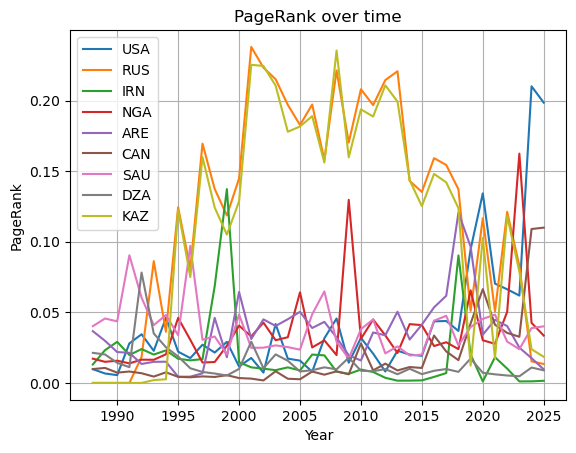

In [52]:
import matplotlib.pyplot as plt

pagerank_countries = ["USA", "RUS", "IRN", "NGA", "ARE", "CAN", "SAU", "DZA", "KAZ"]
years = [i for i in range(start_year,end_year)]

data = {c: [pageranks[year].get(c, 0.0) for year in years] for c in pagerank_countries}

for c in pagerank_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("PageRank")
plt.title("PageRank over time")
plt.legend()
plt.grid(True)
plt.show()

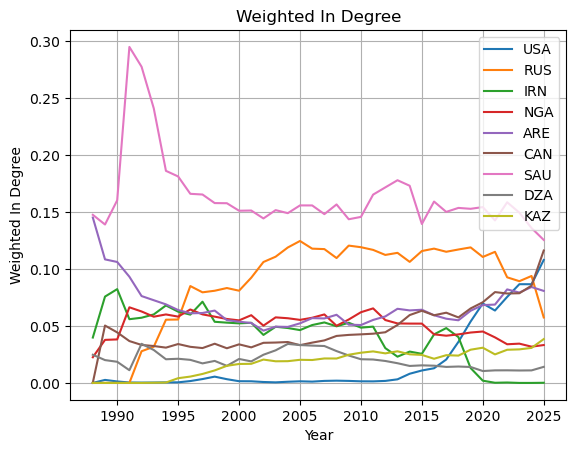

In [53]:
WID_countries = ["USA", "RUS", "IRN", "NGA", "ARE", "CAN", "SAU", "DZA", "KAZ"]
years = [i for i in range(start_year,end_year)]

data = {c: [wgt_in_degree[year].get(c, 0.0) for year in years] for c in WID_countries}

for c in WID_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("Weighted In Degree")
plt.title("Weighted In Degree")
plt.legend()
plt.grid(True)
plt.show()

# Computing Spearman Correlations of how Rankings differ by year

How much does the oil trade hierarchy reshuffle year after year?

In [54]:
pagerank_df = pd.DataFrame.from_dict(pageranks)
wgt_in_degree_df =  pd.DataFrame.from_dict(wgt_in_degree)
wid_matrix = wgt_in_degree_df.corr(method='spearman')
pagerank_matrix = pagerank_df.corr(method='spearman')



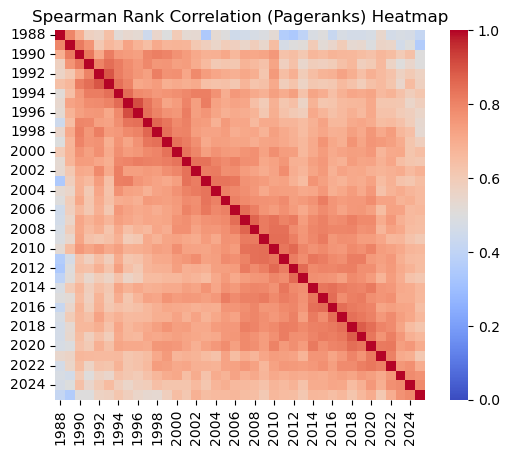

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pagerank_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Pageranks) Heatmap")
plt.show()

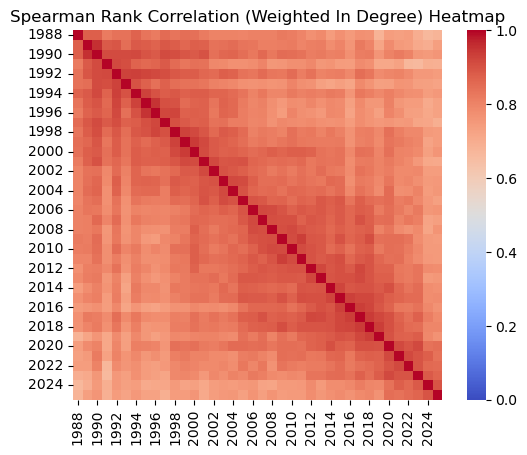

In [56]:
sns.heatmap(wid_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Weighted In Degree) Heatmap")
plt.show()

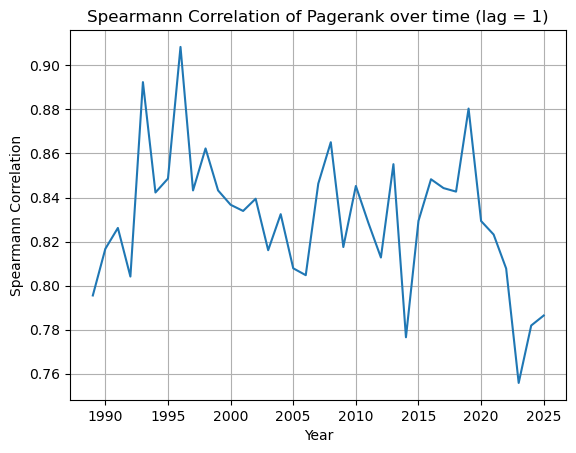

In [57]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_pagerank = [pagerank_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_pagerank)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Pagerank over time (lag = {lag})")
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


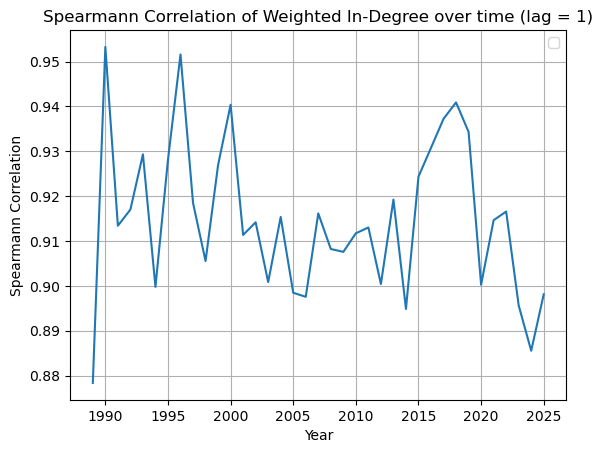

In [58]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_wid = [wid_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_wid)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Weighted In-Degree over time (lag = {lag})")
plt.legend()
plt.grid(True)
plt.show()

## Taking only the top 20 players
To exclude noise from smaller countries, let's only consider the top 20 players (determined by total weighted in degree, so total oil exports from all years)

In [59]:
top20exporters = ['SAU', 'RUS', 'IRQ', 'ARE', 'CAN', 'NGA', 'KWT', 'AGO', 'VEN', 'NOR', 
                    'IRN', 'MEX', 'LBY', 'KAZ','QAT', 'GBR', 'USA', 'DZA', 'BRA', 'NLD']
top20pagerank = ['RUS', 'KAZ', 'NGA', 'GAB', 'USA', 'COG', 'SAU', 'KWT', 'EGY', 'NLD', 
                    'VEN', 'DZA', 'ARE', 'ECU','IRN', 'NOR', 'COL', 'CAN', 'IRQ', 'GBR']


top20pagerank_df = pagerank_df.loc[top20pagerank].copy()
top20wid_df = wgt_in_degree_df.loc[top20exporters].copy()

top20pagerankmatrix  = top20pagerank_df.corr(method='spearman')
top20WIDmatrix  = top20wid_df.corr(method='spearman')



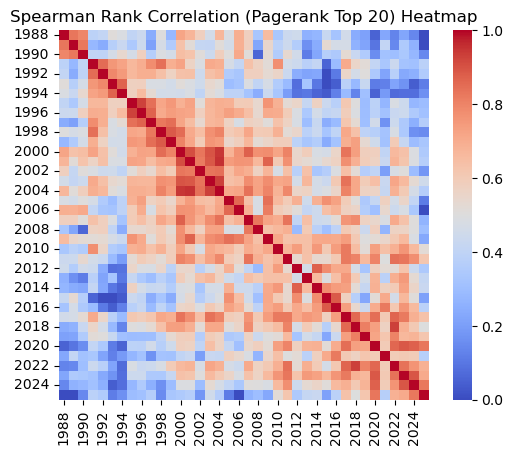

In [63]:
sns.heatmap(top20pagerankmatrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Pagerank Top 20) Heatmap")
plt.show()

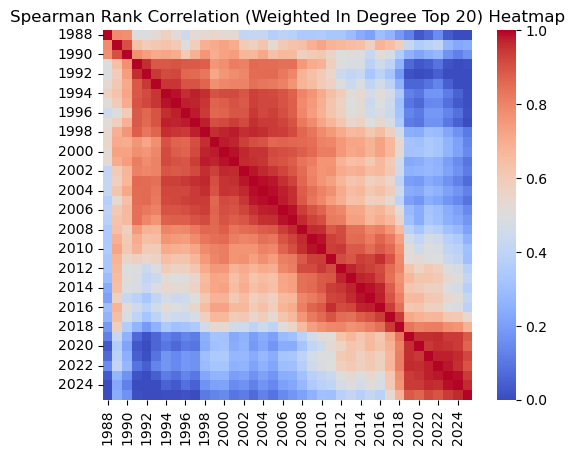

In [61]:
sns.heatmap(top20WIDmatrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Weighted In Degree Top 20) Heatmap")
plt.show()

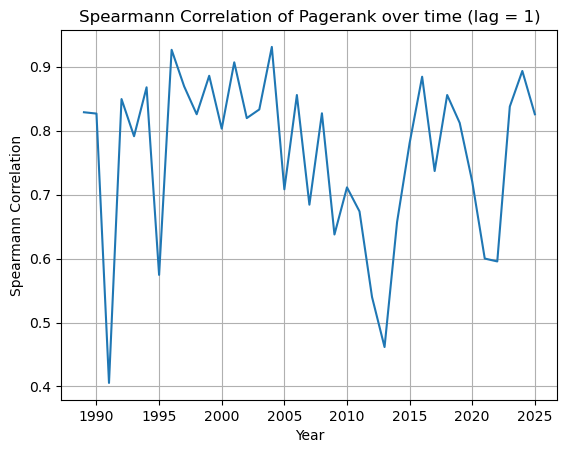

In [62]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_pagerank = [top20pagerankmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_pagerank)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Pagerank over time (lag = {lag})")
plt.grid(True)
plt.show()

The range of values here varies much more widely than it does for weighted in-degree does: the ranking of actual top exporters does not change much

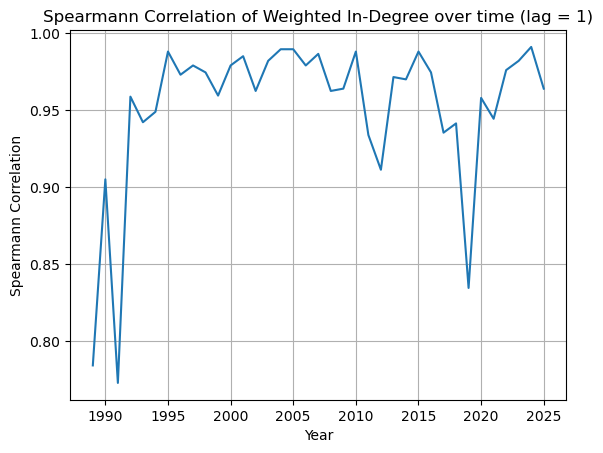

In [64]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_wid = [top20WIDmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_wid)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Weighted In-Degree over time (lag = {lag})")
plt.grid(True)
plt.show()

# Closeness and Betweenness

In [65]:
betweenness = {}
for year in range(start_year, end_year):
        closeness[year] = nx.closeness_centrality(trade_graph_dict[year])
        betweenness[year] = nx.betweenness_centrality(trade_graph_dict[year])


In [66]:
top20closeness = ['USA', 'NLD', 'GBR', 'FRA', 'ARE', 'CHN', 'DEU', 'ITA', 'BEL', 'IND', 
                  'ESP', 'CAN', 'KOR', 'SGP', 'ZAF', 'NGA', 'RUS', 'JPN', 'CHE', 'SWE']
top20btwn = ['USA', 'NLD', 'ARE', 'CHN', 'FRA', 'ZAF', 'NGA', 'RUS', 'SGP', 'DEU', 
                  'GBR', 'IND', 'KOR', 'CAN', 'ROU', 'ESP', 'AUS', 'THA', 'ITA', 'DZA']

closeness_df = pd.DataFrame.from_dict(closeness)
top20closeness_df = closeness_df.loc[top20closeness].copy()
closeness_matrix = closeness_df.corr(method='spearman')
top20closeness_matrix = top20closeness_df.corr(method='spearman')

betweenness_df = pd.DataFrame.from_dict(betweenness)
top20betweenness_df = betweenness_df.loc[top20btwn].copy()
btwnness_matrix = betweenness_df.corr(method='spearman')
top20btwn_matrix = top20betweenness_df.corr(method='spearman')


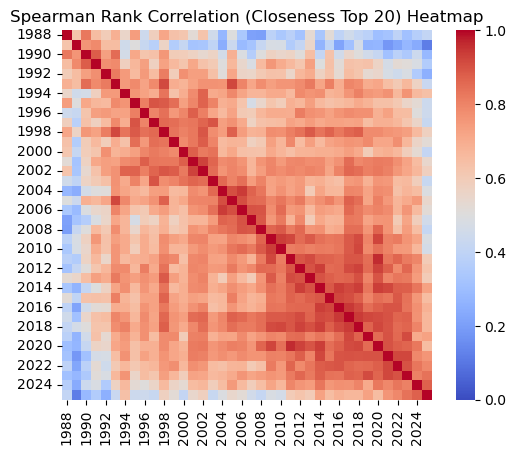

In [67]:
sns.heatmap(top20closeness_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Closeness Top 20) Heatmap")
plt.show()

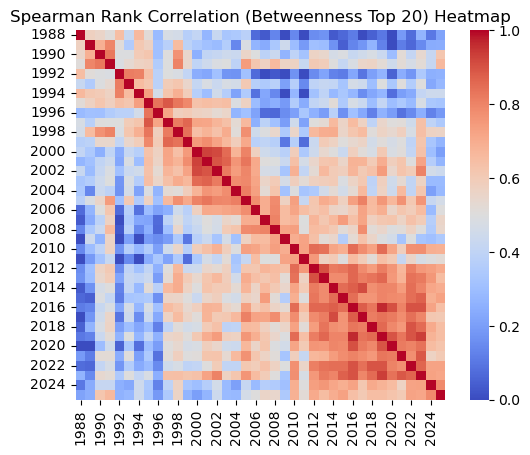

In [68]:
sns.heatmap(top20btwn_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Betweenness Top 20) Heatmap")
plt.show()

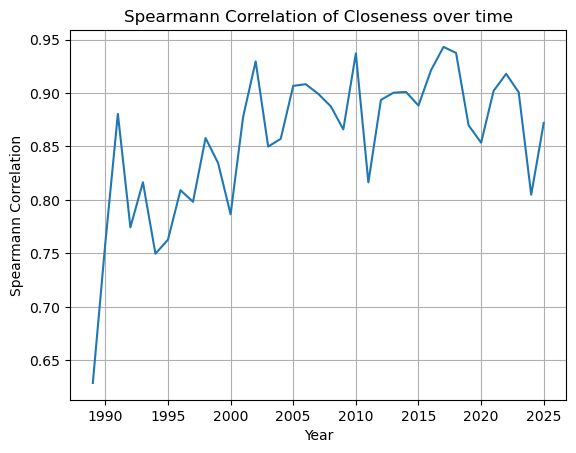

In [69]:
years = [i for i in range(start_year+lag, end_year)]

data_closeness = [top20closeness_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_closeness)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Closeness over time")
plt.grid(True)
plt.show()

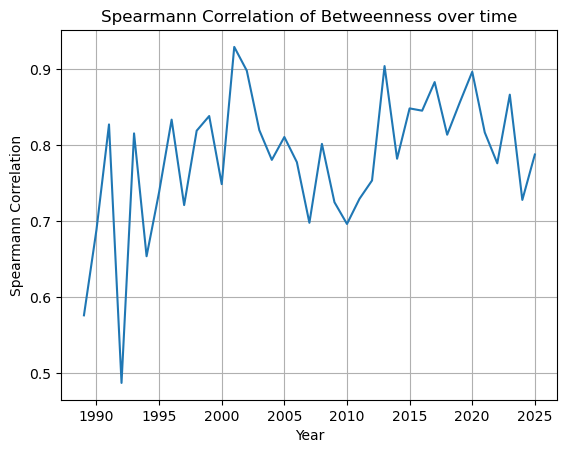

In [70]:
years = [i for i in range(start_year+lag, end_year)]

data_btwn = [top20btwn_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_btwn)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Betweenness over time")
plt.grid(True)
plt.show()

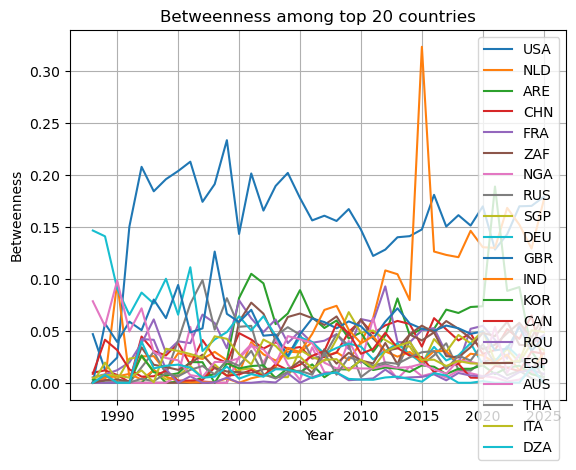

In [71]:
years = [i for i in range(start_year,end_year)]

data_btwn_countryview = {c: [betweenness[year].get(c, 0.0) for year in years] for c in top20btwn}

for c in top20btwn:
    plt.plot(years, data_btwn_countryview[c], label=c)

plt.xlabel("Year")
plt.ylabel("Betweenness")
plt.title("Betweenness among top 20 countries")
plt.legend()
plt.grid(True)
plt.show()

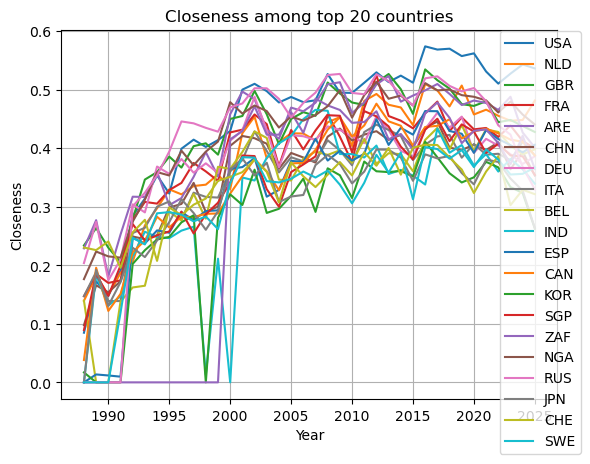

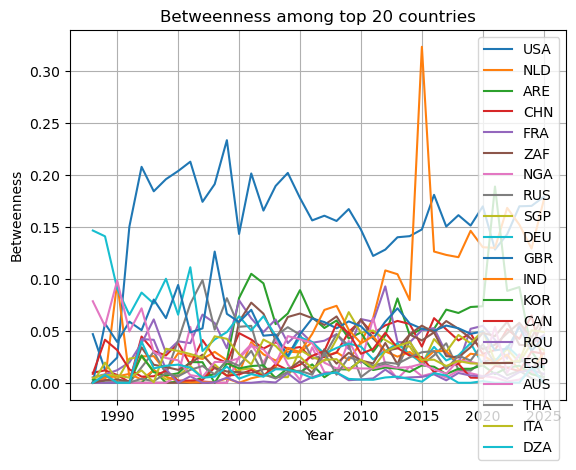

In [72]:
data_close_countryview = {c: [closeness[year].get(c, 0.0) for year in years] for c in top20closeness}

for c in top20closeness:
    plt.plot(years, data_close_countryview[c], label=c)

plt.xlabel("Year")
plt.ylabel("Closeness")
plt.title("Closeness among top 20 countries")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right', borderaxespad=0.1)
plt.grid(True)
plt.show()

years = [i for i in range(start_year,end_year)]

data_btwn_countryview = {c: [betweenness[year].get(c, 0.0) for year in years] for c in top20btwn}

for c in top20btwn:
    plt.plot(years, data_btwn_countryview[c], label=c)

plt.xlabel("Year")
plt.ylabel("Betweenness")
plt.title("Betweenness among top 20 countries")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
betweenness[year].get('NLD', 0.0)

0.15208941167684029

# Community Structure

How much is the oil trade graph organized into communities? (Using the Louvain Algorithm)

In [73]:
def louvain_communities(
    G, weight="weight", resolution=1, threshold=0.0000001, max_level=None, seed=None
):
    r"""Find the best partition of a graph using the Louvain Community Detection
    Algorithm.

    Louvain Community Detection Algorithm is a simple method to extract the community
    structure of a network. This is a heuristic method based on modularity optimization. [1]_

    The algorithm works in 2 steps. On the first step it assigns every node to be
    in its own community and then for each node it tries to find the maximum positive
    modularity gain by moving each node to all of its neighbor communities. If no positive
    gain is achieved the node remains in its original community.

    The modularity gain obtained by moving an isolated node $i$ into a community $C$ can
    easily be calculated by the following formula (combining [1]_ [2]_ and some algebra):

    .. math::
        \Delta Q = \frac{k_{i,in}}{2m} - \gamma\frac{ \Sigma_{tot} \cdot k_i}{2m^2}

    where $m$ is the size of the graph, $k_{i,in}$ is the sum of the weights of the links
    from $i$ to nodes in $C$, $k_i$ is the sum of the weights of the links incident to node $i$,
    $\Sigma_{tot}$ is the sum of the weights of the links incident to nodes in $C$ and $\gamma$
    is the resolution parameter.

    For the directed case the modularity gain can be computed using this formula according to [3]_

    .. math::
        \Delta Q = \frac{k_{i,in}}{m}
        - \gamma\frac{k_i^{out} \cdot\Sigma_{tot}^{in} + k_i^{in} \cdot \Sigma_{tot}^{out}}{m^2}

    where $k_i^{out}$, $k_i^{in}$ are the outer and inner weighted degrees of node $i$ and
    $\Sigma_{tot}^{in}$, $\Sigma_{tot}^{out}$ are the sum of in-going and out-going links incident
    to nodes in $C$.

    The first phase continues until no individual move can improve the modularity.

    The second phase consists in building a new network whose nodes are now the communities
    found in the first phase. To do so, the weights of the links between the new nodes are given by
    the sum of the weight of the links between nodes in the corresponding two communities. Once this
    phase is complete it is possible to reapply the first phase creating bigger communities with
    increased modularity.

    The above two phases are executed until no modularity gain is achieved (or is less than
    the `threshold`, or until `max_levels` is reached).

    Be careful with self-loops in the input graph. These are treated as
    previously reduced communities -- as if the process had been started
    in the middle of the algorithm. Large self-loop edge weights thus
    represent strong communities and in practice may be hard to add
    other nodes to.  If your input graph edge weights for self-loops
    do not represent already reduced communities you may want to remove
    the self-loops before inputting that graph.

    Parameters
    ----------
    G : NetworkX graph
    weight : string or None, optional (default="weight")
        The name of an edge attribute that holds the numerical value
        used as a weight. If None then each edge has weight 1.
    resolution : float, optional (default=1)
        If resolution is less than 1, the algorithm favors larger communities.
        Greater than 1 favors smaller communities
    threshold : float, optional (default=0.0000001)
        Modularity gain threshold for each level. If the gain of modularity
        between 2 levels of the algorithm is less than the given threshold
        then the algorithm stops and returns the resulting communities.
    max_level : int or None, optional (default=None)
        The maximum number of levels (steps of the algorithm) to compute.
        Must be a positive integer or None. If None, then there is no max
        level and the threshold parameter determines the stopping condition.
    seed : integer, random_state, or None (default)
        Indicator of random number generation state.
        See :ref:`Randomness<randomness>`.

    Returns
    -------
    list
        A list of sets (partition of `G`). Each set represents one community and contains
        all the nodes that constitute it.

    Examples
    --------
    >>> import networkx as nx
    >>> G = nx.petersen_graph()
    >>> nx.community.louvain_communities(G, seed=123)
    [{0, 4, 5, 7, 9}, {1, 2, 3, 6, 8}]

    Notes
    -----
    The order in which the nodes are considered can affect the final output. In the algorithm
    the ordering happens using a random shuffle.

    References
    ----------
    .. [1] Blondel, V.D. et al. Fast unfolding of communities in
       large networks. J. Stat. Mech 10008, 1-12(2008). https://doi.org/10.1088/1742-5468/2008/10/P10008
    .. [2] Traag, V.A., Waltman, L. & van Eck, N.J. From Louvain to Leiden: guaranteeing
       well-connected communities. Sci Rep 9, 5233 (2019). https://doi.org/10.1038/s41598-019-41695-z
    .. [3] Nicolas Dugué, Anthony Perez. Directed Louvain : maximizing modularity in directed networks.
        [Research Report] Université d’Orléans. 2015. hal-01231784. https://hal.archives-ouvertes.fr/hal-01231784

    See Also
    --------
    louvain_partitions
    :any:`leiden_communities`
    """

    partitions = louvain_partitions(G, weight, resolution, threshold, seed)
    if max_level is not None:
        if max_level <= 0:
            raise ValueError("max_level argument must be a positive integer or None")
        partitions = itertools.islice(partitions, max_level)
    final_partition = deque(partitions, maxlen=1)
    return final_partition.pop()

In [74]:
communities = {}
partitions = {}
num_communities = {}
modularity = {}

for year in range(start_year, end_year):
    communities[year] = nx.community.louvain_communities(trade_graph_dict[year], weight="weight")
    partitions[year] = nx.community.louvain_partitions(trade_graph_dict[year], weight="weight")
    num_communities[year] = len(communities[year])
    modularity[year] = nx.community.modularity(trade_graph_dict[year],  communities[year], weight="weight")
    

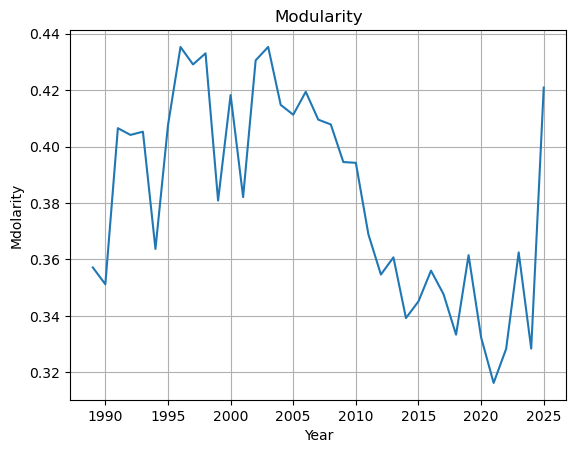

In [75]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_modularity = [modularity[i] for i in years]

plt.plot(years, data_modularity)

plt.xlabel("Year")
plt.ylabel("Mdolarity")
plt.title(f"Modularity")
plt.grid(True)
plt.show()

# CON Scores    

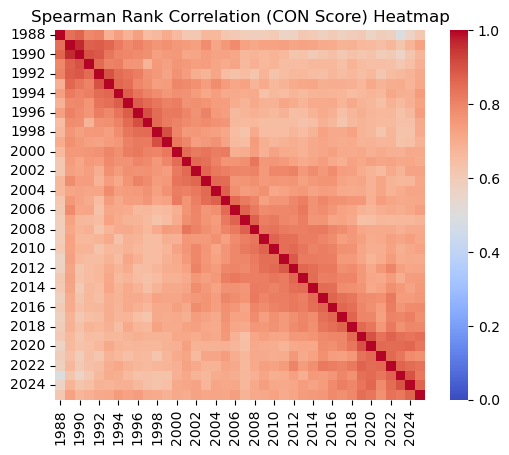

In [78]:
conscore_df = pd.DataFrame.from_dict(con_scores)
conscore_matrix = conscore_df.corr(method='spearman')

sns.heatmap(conscore_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (CON Score) Heatmap")
plt.show()

In [ ]:
# Redo with only the top 20 contenders
top_20CON = (
    conscore_df
    .sum(axis=1, skipna=True)
    .sort_values(ascending=False)
    .head(10)
)
top20CON = list(top_20CON.keys())
top20CON

['USA',
 'NLD',
 'FRA',
 'CHN',
 'ESP',
 'DEU',
 'KOR',
 'SGP',
 'CAN',
 'GBR',
 'ITA',
 'IND',
 'JPN',
 'THA',
 'BEL',
 'PRT',
 'SWE',
 'MYS',
 'AUS',
 'GRC']

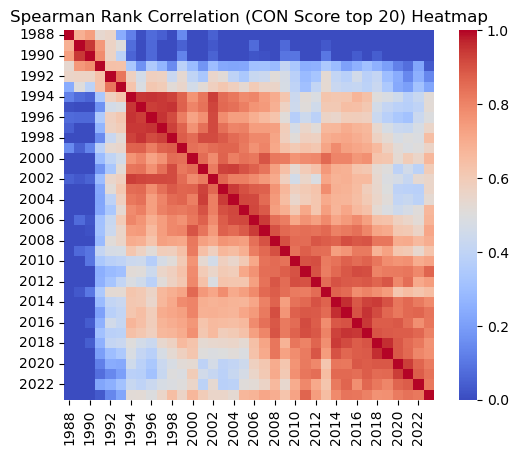

In [ ]:
top20con_df = conscore_df.loc[top20CON].copy()
top20conscore_matrix = top20con_df.corr(method='spearman')

sns.heatmap(top20conscore_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (CON Score top 20) Heatmap")
plt.show()

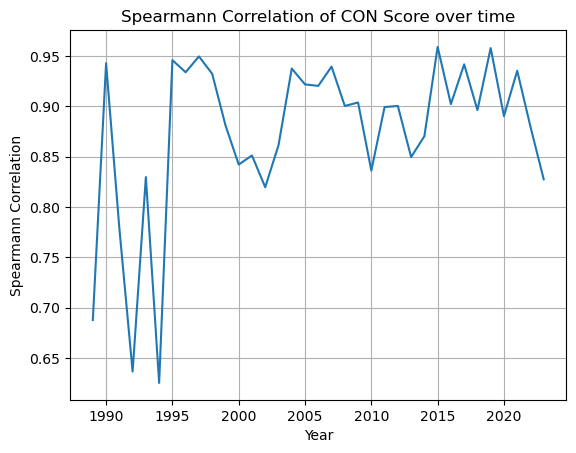

In [ ]:
years = [i for i in range(start_year+lag, end_year)]

data_con = [top20conscore_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_con)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of CON Score over time")
plt.grid(True)
plt.show()

# Import Oil Price Data

In [ ]:
oil_prices = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/PET_PRI_SPT_S1_A.csv", index_col=False)
oil_prices = oil_prices[['Year', 'Cushing, OK WTI Spot Price FOB (Dollars per Barrel)']]
oil_prices.columns = ['Year', 'Price']
oil_prices = oil_prices[(oil_prices['Year'] >= start_year) & (oil_prices['Year'] <= end_year-1) ].copy()
oil_prices

,Year,Price
2,1988.0,15.97
3,1989.0,19.64
4,1990.0,24.53
5,1991.0,21.54
6,1992.0,20.58
7,1993.0,18.43
8,1994.0,17.20
9,1995.0,18.43
10,1996.0,22.12
11,1997.0,20.61


In [ ]:
CPI_df = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/CPIAUCSL (2).csv", index_col=False)
CPI_df.columns = ['Year', 'CPI']
CPI_df["Year"] = pd.to_datetime(CPI_df["Year"]).dt.year
CPI_df

,Year,CPI
0,1987,113.617
1,1988,118.275
2,1989,123.942
3,1990,130.658
4,1991,136.167
5,1992,140.308
6,1993,144.475
7,1994,148.225
8,1995,152.383
9,1996,156.858


In [ ]:
# Turn dataframes into dictionaries

oil_prices_dict = oil_prices.set_index("Year")["Price"].to_dict()
CPI_dict = CPI_df.set_index("Year")["CPI"].to_dict()

In [ ]:
oil_prices_dict

{1986.0: 15.05,
 1987.0: 19.2,
 1988.0: 15.97,
 1989.0: 19.64,
 1990.0: 24.53,
 1991.0: 21.54,
 1992.0: 20.58,
 1993.0: 18.43,
 1994.0: 17.2,
 1995.0: 18.43,
 1996.0: 22.12,
 1997.0: 20.61,
 1998.0: 14.42,
 1999.0: 19.34,
 2000.0: 30.38,
 2001.0: 25.98,
 2002.0: 26.18,
 2003.0: 31.08,
 2004.0: 41.51,
 2005.0: 56.64,
 2006.0: 66.05,
 2007.0: 72.34,
 2008.0: 99.67,
 2009.0: 61.95,
 2010.0: 79.48,
 2011.0: 94.88,
 2012.0: 94.05,
 2013.0: 97.98,
 2014.0: 93.17,
 2015.0: 48.66,
 2016.0: 43.29,
 2017.0: 50.8,
 2018.0: 65.23,
 2019.0: 56.99,
 2020.0: 39.16,
 2021.0: 68.13,
 2022.0: 94.9,
 2023.0: 77.58,
 2024.0: 76.63,
 2025.0: 65.39,
 nan: nan}

In [ ]:
# Make dictionary of adjusted oil prices
adjusted_oilprices = {}

for year in range(start_year, end_year):
    inflation_factor = CPI_dict[end_year] / CPI_dict[year]
    adjusted_oilprices[year] = oil_prices_dict[year] * inflation_factor



In [ ]:
adjusted_oilprices

{1988: 42.356855294863664,
 1989: 49.708966452050156,
 1990: 58.89430375484089,
 1991: 49.623292868316106,
 1992: 46.01237876671323,
 1993: 40.01698660667935,
 1994: 36.40145454545454,
 1995: 37.94028297119757,
 1996: 44.23746165321501,
 1997: 40.27606777760473,
 1998: 27.750326118963482,
 1999: 36.41979865892678,
 2000: 55.34603953726072,
 2001: 46.0335628833836,
 2002: 45.659368533416355,
 2003: 52.98768391304347,
 2004: 68.930929235395,
 2005: 90.99261380571218,
 2006: 102.79796832673473,
 2007: 109.445719770044,
 2008: 145.2529553922343,
 2009: 90.57204623307622,
 2010: 114.33040334562263,
 2011: 132.3282467333265,
 2012: 128.5065156411976,
 2013: 131.94190236615268,
 2014: 123.47017578100247,
 2015: 64.40681800153584,
 2016: 56.58209795629257,
 2017: 65.01221192798657,
 2018: 81.49151947431302,
 2019: 69.9293535378032,
 2020: 47.45655375961925,
 2021: 78.87222985315879,
 2022: 101.73374956429026,
 2023: 79.87020423166165}

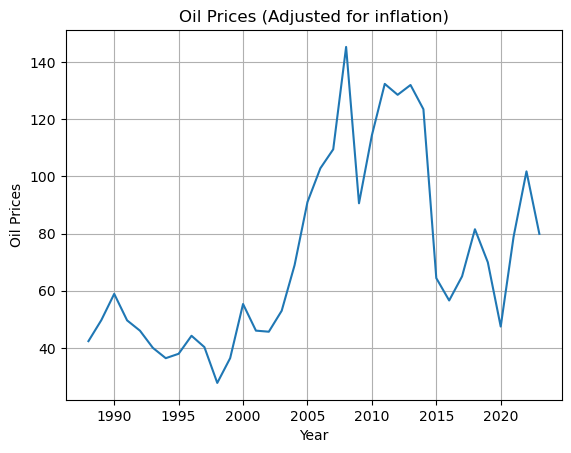

In [ ]:
years = [i for i in range(start_year, end_year)]

data_oil = [adjusted_oilprices[i] for i in range(start_year, end_year)]

plt.plot(years, data_oil)

plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title(f"Oil Prices (Adjusted for inflation)")
plt.grid(True)
plt.show()

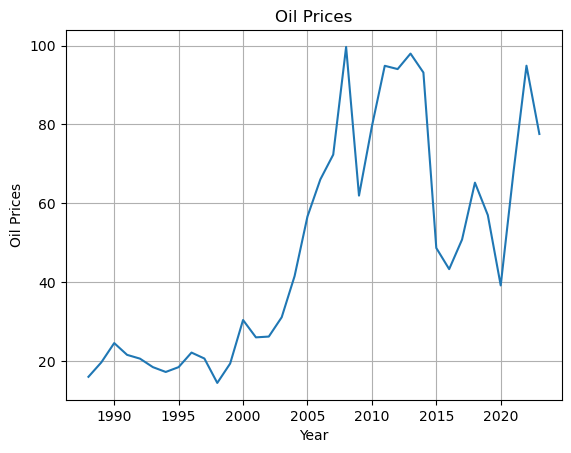

In [ ]:
years = [i for i in range(start_year, end_year)]

data_oil_notadjusted = [oil_prices_dict[i] for i in range(start_year, end_year)]

plt.plot(years, data_oil_notadjusted)

plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title(f"Oil Prices")
plt.grid(True)
plt.show()




2.431638418079096 60
Average = 2.431638418079096
2.45981981981982 75
Average = 2.45981981981982
2.5025991792065665 86
0 1
Average = 2.4738336713995945
2.482051282051282 105
Average = 2.482051282051282
2.5312407898614797 117
0 1
Average = 2.5097895967270603
2.6606791338582676 128
1.0 2
0 1
Average = 2.615014726212658
2.601138565891473 129
0 1
0 1
0 1
0 1
1.0 2
Average = 2.500347222222222
2.5296174208370794 142
0 1
0 1
0 1
0 1
Average = 2.4603128339648306
2.4648086915446386 146
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3520396664412893
2.5267162944582298 156
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.388895405669599
2.501298701298701 155
0 1
0 1
Average = 2.469435023575151
2.443907675791734 162
0 1
1.0 2
0 1
0 1
Average = 2.382712835199167
2.5376310338334065 179
0 1
Average = 2.523533083645443
2.4966933518969716 170
Average = 2.4966933518969716
2.471192682347351 184
Average = 2.471192682347351
2.47298927188472 178
Average = 2.47298927188472
2.5330838679021146 184
Average = 2.533083867

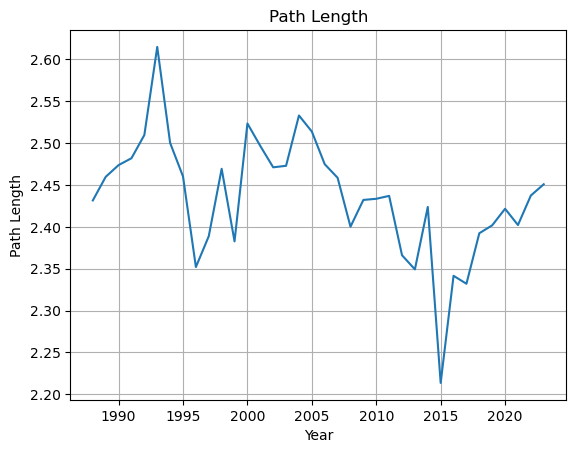

In [ ]:
avg_pathlength = {year: safe_avgpathlength(trade_graph_dict[year].to_undirected()) for year in range(start_year, end_year)}

avg_pathlength_data = [avg_pathlength[i] for i in range(start_year, end_year)]

plt.plot(years, avg_pathlength_data)

plt.xlabel("Year")
plt.ylabel("Path Length")
plt.title(f"Path Length")
plt.grid(True)
plt.show()

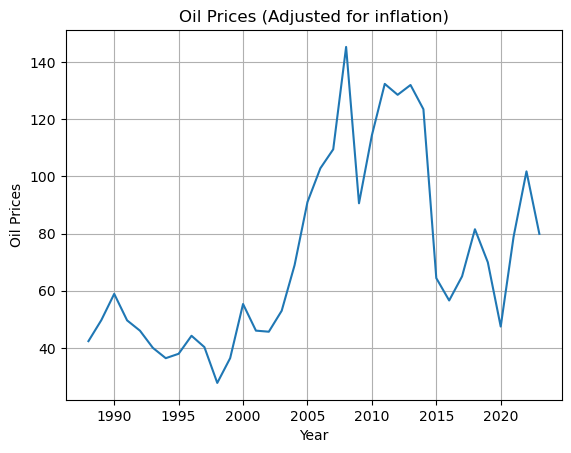

In [ ]:
years = [i for i in range(start_year, end_year)]

data_oil = [adjusted_oilprices[i] for i in range(start_year, end_year)]

plt.plot(years, data_oil)

plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title(f"Oil Prices (Adjusted for inflation)")
plt.grid(True)
plt.show()

In [ ]:
x = oil_prices[(oil_prices['Year'] >= start_year) & (oil_prices['Year'] <= end_year) ].copy()

In [ ]:
avg_pathlength_df = pd.DataFrame(list(avg_pathlength.items()), columns=["year", "pathlength"])
avg_pathlength_df

,year,pathlength
0,1988,2.431638
1,1989,2.459820
2,1990,2.473834
3,1991,2.482051
4,1992,2.509790
5,1993,2.615015
6,1994,2.500347
7,1995,2.460313
8,1996,2.352040
9,1997,2.388895


In [ ]:
rho = oil_prices['Price'].corr(avg_pathlength_df['pathlength'])
rho

-0.5846589765815476

In [ ]:
def diameter_lcc(G):
    if nx.is_connected(G):
        return nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc)
        return nx.diameter(G_sub)

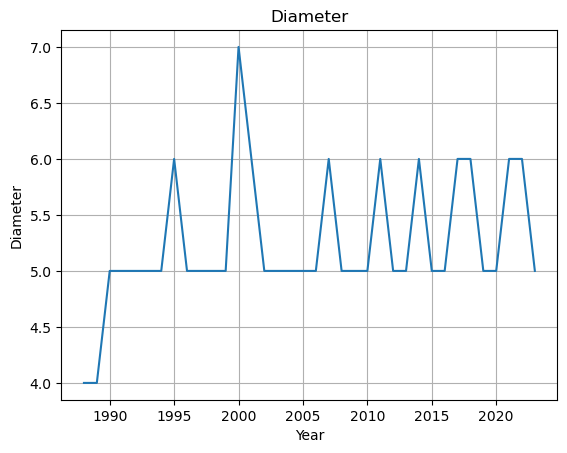

In [ ]:
diameter_dict = {year: diameter_lcc(trade_graph_dict[year].to_undirected()) for year in range(start_year, end_year)}

diameter_data = [diameter_dict[i] for i in range(start_year, end_year)]

plt.plot(years, diameter_data)

plt.xlabel("Year")
plt.ylabel("Diameter")
plt.title(f"Diameter")
plt.grid(True)
plt.show()

# Clique Counting the Oil Trade k3 graph

In [ ]:
pruned_dict_k3[2010]

In [ ]:

def three_profile(g: nx.Graph):
    """Computes the number of 3-node subgraphs that exists in a NetworkX Graph
    Assumes no loops.

    Returns a 4-tuple: (number of empty subgraphs, number of discs, number of wedges, number of triangles)
    """
    neighbor_sets = {}
    for v in g.nodes:
        neighbor_sets[v] = set(g.neighbors(v))

    triangle_counts = 0  # 3 edges
    wedge_counts = 0  # 2 edges
    disc_counts = 0  # 1 edge
    empty_counts = 0  # 0 edges

    for e in g.edges:
        u = e[0]
        v = e[1]
        num_u_neighbors = len(neighbor_sets[u])
        num_v_neighbors = len(neighbor_sets[v])
        num_common_neighbors = len(neighbor_sets[u].intersection(neighbor_sets[v]))

        triangle_counts += num_common_neighbors

        # to count wedges, split up wedges centered at u and centered at v
        # to count wedges centered at u containing uv, count all neighbors of u, except for v, and subtract common neighbors
        wedge_counts += num_u_neighbors - num_common_neighbors - 1
        # to count wedges centered at v containing uv, count all neighbors of v, except for u, and subtract common neighbors
        wedge_counts += num_v_neighbors - num_common_neighbors - 1  # wedges centered at v containing uv

        # to get disc counts, number of nodes that aren't adjacent to u or v. |V(g)| - num of distinct neighbors of u union distinct neighbors of v
        # to calculate number of distinct neighbors, take both neighbor sets combined, and substract the common ones (they're counted twice)
        disc_counts += g.number_of_nodes() - num_u_neighbors - num_v_neighbors + num_common_neighbors

    wedge_counts = wedge_counts / 2  # each wedge counted twice, once per edge in wedge
    triangle_counts = triangle_counts / 3  # each triangle counted thrice, once per edge in triangle
    empty_counts = (g.number_of_nodes() * (g.number_of_nodes() - 1) * (
                g.number_of_nodes() - 2) / 6) - triangle_counts - wedge_counts - disc_counts

    return empty_counts, disc_counts, wedge_counts, triangle_counts

In [ ]:
three_profile(pruned_dict_k3[2010])

(1118539.0, 78991, 577.0, 37.0)

In [ ]:
three_profile(pruned_dict_k3[2010].to_undirected())

(1123663.0, 71101, 3289.0, 91.0)

In [ ]:
triangle_dict

{1988: (31455.0, 2572, 193.0, 0.0),
 1989: (61023.0, 6076, 419.0, 7.0),
 1990: (97118.0, 8326, 544.0, 7.0),
 1991: (174907.0, 11842, 688.0, 23.0),
 1992: (247208.0, 18794, 888.0, 26.0),
 1993: (340589.0, 24441, 1083.0, 32.0),
 1994: (372749.0, 26996, 1220.0, 30.0),
 1995: (471772.0, 34645, 1618.0, 45.0),
 1996: (543885.0, 39369, 1947.0, 75.0),
 1997: (689076.0, 43753, 2245.0, 56.0),
 1998: (588486.0, 41878, 2261.0, 85.0),
 1999: (709822.0, 49544, 2906.0, 83.0),
 2000: (892982.0, 59820, 2956.0, 102.0),
 2001: (747060.0, 54218, 3056.0, 106.0),
 2002: (951813.0, 65925, 3517.0, 129.0),
 2003: (858810.0, 61851, 3404.0, 111.0),
 2004: (954338.0, 63750, 3204.0, 92.0),
 2005: (1017775.5, 68524, 3431.5, 105.0),
 2006: (1035833.3333333333, 68103, 3362.0, 115.66666666666667),
 2007: (1035670.0, 68410, 3238.0, 96.0),
 2008: (980168.0, 71334, 3612.0, 126.0),
 2009: (947068.0, 70661, 3548.0, 107.0),
 2010: (1123663.0, 71101, 3289.0, 91.0),
 2011: (1191839.0, 78372, 3891.0, 94.0),
 2012: (1013923.833

In [ ]:
triangle_data

[(31455.0, 2572, 193.0, 0.0),
 (61023.0, 6076, 419.0, 7.0),
 (97118.0, 8326, 544.0, 7.0),
 (174907.0, 11842, 688.0, 23.0),
 (247208.0, 18794, 888.0, 26.0),
 (340589.0, 24441, 1083.0, 32.0),
 (372749.0, 26996, 1220.0, 30.0),
 (471772.0, 34645, 1618.0, 45.0),
 (543885.0, 39369, 1947.0, 75.0),
 (689076.0, 43753, 2245.0, 56.0),
 (588486.0, 41878, 2261.0, 85.0),
 (709822.0, 49544, 2906.0, 83.0),
 (892982.0, 59820, 2956.0, 102.0),
 (747060.0, 54218, 3056.0, 106.0),
 (951813.0, 65925, 3517.0, 129.0),
 (858810.0, 61851, 3404.0, 111.0),
 (954338.0, 63750, 3204.0, 92.0),
 (1017775.5, 68524, 3431.5, 105.0),
 (1035833.3333333333, 68103, 3362.0, 115.66666666666667),
 (1035670.0, 68410, 3238.0, 96.0),
 (980168.0, 71334, 3612.0, 126.0),
 (947068.0, 70661, 3548.0, 107.0),
 (1123663.0, 71101, 3289.0, 91.0),
 (1191839.0, 78372, 3891.0, 94.0),
 (1013923.8333333333, 72132, 3678.5, 101.66666666666667),
 (933588.0, 67454, 3587.0, 102.0),
 (1016827.1666666667, 69477, 3440.5, 91.33333333333333),
 (986339.0, 6

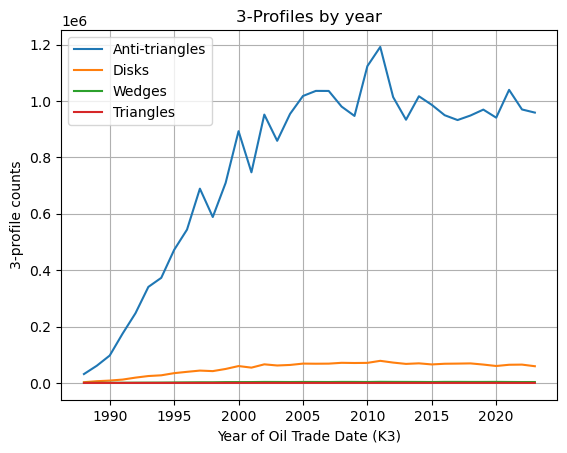

In [ ]:
years = [i for i in range(start_year, end_year)]
triangle_dict = {year: three_profile(pruned_dict_k3[year].to_undirected()) for year in range(start_year, end_year)}

clique_types = [0, 1, 2, 3] # 0: triangles, 1: wedges, 2: discs, 3: anticliques
triangle_data = {c: [triangle_dict[i][c] for i in range(start_year, end_year)] for c in clique_types}

for c in clique_types:
    plt.plot(years, triangle_data[c], label=c)

plt.xlabel("Year of Oil Trade Date (K3)")
plt.ylabel("3-profile counts")
plt.title(f"3-Profiles by year")
plt.legend(['Anti-triangles', 'Disks', 'Wedges', 'Triangles'])
plt.grid(True)
plt.show()

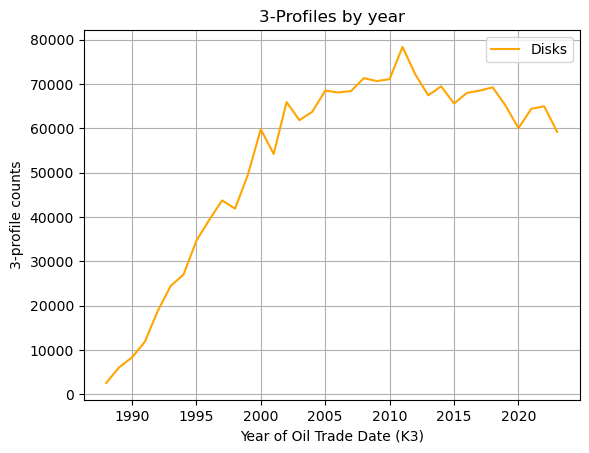

In [ ]:
years = [i for i in range(start_year, end_year)]
triangle_dict = {year: three_profile(pruned_dict_k3[year].to_undirected()) for year in range(start_year, end_year)}

clique_types = [0,1,2,3] # 0: triangles, 1: wedges, 2: discs, 3: anticliques
triangle_data = {c: [triangle_dict[i][c] for i in range(start_year, end_year)] for c in clique_types}

# c=2 for the wedge count
plt.plot(years, triangle_data[1], label=2, color='orange')

plt.xlabel("Year of Oil Trade Date (K3)")
plt.ylabel("3-profile counts")
plt.title(f"3-Profiles by year")
plt.legend(['Disks'])
plt.grid(True)
plt.show()

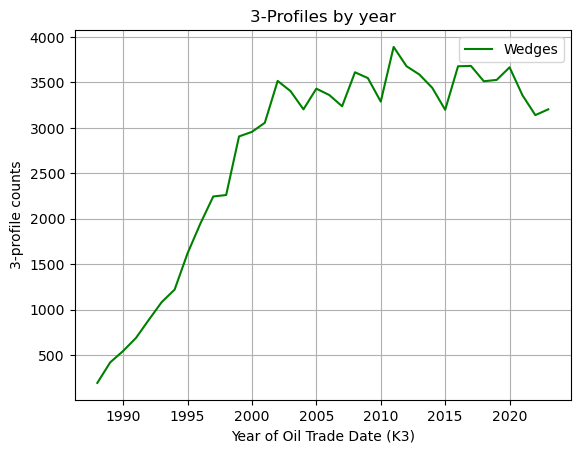

In [ ]:
years = [i for i in range(start_year, end_year)]
triangle_dict = {year: three_profile(pruned_dict_k3[year].to_undirected()) for year in range(start_year, end_year)}

clique_types = [0,1,2,3] # 0: triangles, 1: wedges, 2: discs, 3: anticliques
triangle_data = {c: [triangle_dict[i][c] for i in range(start_year, end_year)] for c in clique_types}

# c=2 for the wedge count
plt.plot(years, triangle_data[2], label=2, color='g')

plt.xlabel("Year of Oil Trade Date (K3)")
plt.ylabel("3-profile counts")
plt.title(f"3-Profiles by year")
plt.legend(['Wedges'])
plt.grid(True)
plt.show()

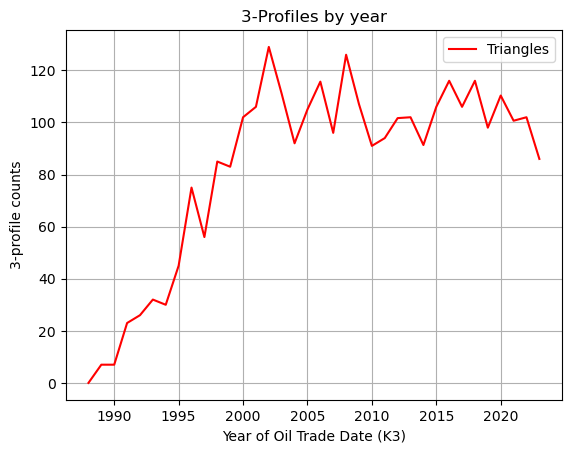

In [ ]:
years = [i for i in range(start_year, end_year)]
triangle_dict = {year: three_profile(pruned_dict_k3[year].to_undirected()) for year in range(start_year, end_year)}

clique_types = [3] # 0: triangles, 1: wedges, 2: discs, 3: anticliques
triangle_data = {c: [triangle_dict[i][c] for i in range(start_year, end_year)] for c in clique_types}

for c in clique_types:
    plt.plot(years, triangle_data[c], label=c, color='r')

plt.xlabel("Year of Oil Trade Date (K3)")
plt.ylabel("3-profile counts")
plt.title(f"3-Profiles by year")
plt.legend(['Triangles'])
plt.grid(True)
plt.show()

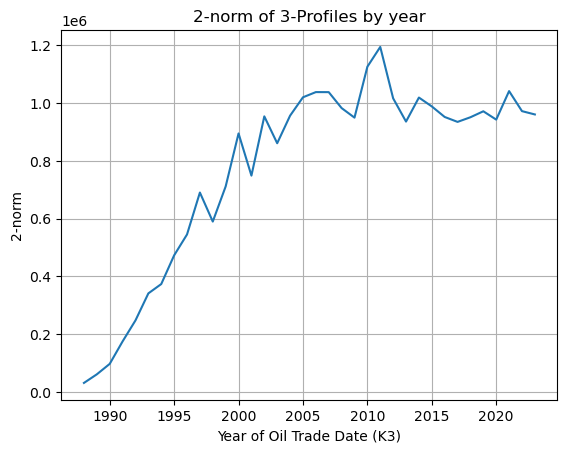

In [ ]:
years = [i for i in range(start_year, end_year)]
clique_norms = {year: np.linalg.norm(three_profile(pruned_dict_k3[year].to_undirected())) for year in range(start_year, end_year)}

clique_data = [clique_norms[i] for i in range(start_year, end_year)]

plt.plot(years, clique_data)

plt.xlabel("Year of Oil Trade Date (K3)")
plt.ylabel("2-norm")
plt.title(f"2-norm of 3-Profiles by year")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
norm_2 = np.linalg.norm(three_profile(pruned_dict_k3[year].to_undirected()))
print(norm_2)

960708.19082175


In [ ]:
import networkx as nx

def two_hop_histogram(g: nx.Graph):
    """For each node v in g, compute the number 2-paths from v to the other nodes of g

    Assumes that g is a simple graph with no loops.
    Returns a dictionary, keys are the nodes of g, and values are another dictionary that counts the number of 2-paths
    to other nodes. For example, two_hop_profile[v][u] is equal to the number of 2 paths from v to u.
    """
    two_hop_profile = {}

    neighbor_sets = {}
    # initialize tuples for each vertex
    for v in g.nodes:
        neighbor_sets[v] = set(g.neighbors(v))
        two_hop_profile[v] = dict()
        for u in g.nodes:
            two_hop_profile[v][u] = 0

            # below approach works well if instead of a dictionary, the 2-path counts were a vector
            # when a vector, it is easy to add just add two vectors together instead of neighbour checks in the next loop
            # if u in neighbor_sets[v]:
            #     two_hop_profile[v][u] = 1
            # else:
            #     two_hop_profile[v][u] = 0


    for e in g.edges:
        u = e[0]
        v = e[1]

        # for every neighbour a of v, if ua is not an edge, then uva is a 2-path
        # then, for every neighbour a of v that is not a neighbour of u, increase ua path count by 1
        for a in neighbor_sets[v].difference(neighbor_sets[u], {u}):
            two_hop_profile[u][a] += 1

        # same goes for u
        for a in neighbor_sets[u].difference(neighbor_sets[v], {v}):
            two_hop_profile[v][a] += 1

    return two_hop_profile


class vertex_3_data:
    __slots__ = ('num_triangles', 'num_wedges', 'num_discs', 'num_anti_triangle', 'num_wedge_center', 'num_wedge_leaf',
                 'num_disc_leaf', 'num_disc_alone',
                 'n1', 'n2c', 'n2e', 'n3',
                 'n1_double', 'n2c_double', 'n2e_double', 'n3_double',
                 'n1_n2c', 'n1_n2e', 'n1_n3', 'n2c_n2e', 'n2c_n3', 'n2e_n3',
                 'triangle_pairs'
                 )

    def __init__(self):
        self.num_triangles = 0
        self.num_wedges = 0
        self.num_discs = 0
        self.num_anti_triangle = 0

        self.num_wedge_center = 0
        self.num_wedge_leaf = 0
        self.num_disc_leaf = 0
        self.num_disc_alone = 0

        # 3-profile algebraic variables
        self.n1 = 0 # number of disc leafs
        self.n2c = 0 # number of wedge center (scaled by 2)
        self.n2e = 0 # number of wedge leafs
        self.n3 = 0 # number of triangles (scaled by 2)

        # 4-profile equation variables
        self.n1_double = 0
        self.n2c_double = 0
        self.n2e_double = 0
        self.n3_double = 0
        self.n1_n2c = 0
        self.n1_n2e = 0
        self.n1_n3 = 0
        self.n2c_n2e = 0
        self.n2c_n3 = 0
        self.n2e_n3 = 0

        self.triangle_pairs = set() # set of 2-tuples that form triangles with v


def three_profile_vertex(g: nx.Graph):
    """Computes the 3-profile of a graph g, the number of subgraphs of each graph on 3 vertices.

    For each vertex v, three_profile_vertex computes the number of each 3 node graph v is in.
    For example, three_profile_vertex counts the number of different triangles contained in each vertex.

    Returns a dict where the keys are the nodes of g, and the values are vertex_3_data objects, that contain the counts of different 3-vertex subgraphs.
    """
    vertex_profile = {}

    neighbor_sets = {}
    for v in g.nodes:
        neighbor_sets[v] = set(g.neighbors(v))
        g.nodes[v]['3_profile'] = vertex_3_data()

    for e in g.edges:
        u = e[0]
        v = e[1]
        num_u_neighbors = len(neighbor_sets[u])
        num_v_neighbors = len(neighbor_sets[v])
        common_neighbors = neighbor_sets[u].intersection(neighbor_sets[v])
        n3_a = len(common_neighbors)

        g.nodes[v]['3_profile'].n3 += n3_a
        g.nodes[u]['3_profile'].n3 += n3_a

        g.nodes[v]['3_profile'].n3_double += (n3_a * (n3_a - 1)) / 2
        g.nodes[u]['3_profile'].n3_double += (n3_a * (n3_a - 1)) / 2

        for neighbor in common_neighbors:
            g.nodes[v]['3_profile'].triangle_pairs.add(tuple(sorted((u,neighbor)))) # we sort since each triangle will be added twice, triangle auv will be added for u on edge au and uv
            g.nodes[u]['3_profile'].triangle_pairs.add(tuple(sorted((v,neighbor))))

        # to count wedges, split up wedges centered at u and centered at v
        # to count wedges centered at u containing uv, count all neighbors of u, except for v, and subtract common neighbors
        n2c_ua = num_u_neighbors - n3_a - 1
        g.nodes[u]['3_profile'].n2c += n2c_ua
        g.nodes[v]['3_profile'].n2e += n2c_ua

        g.nodes[u]['3_profile'].n2c_double += (n2c_ua * (n2c_ua - 1)) / 2
        g.nodes[v]['3_profile'].n2e_double += (n2c_ua * (n2c_ua - 1)) / 2

        # to count wedges centered at v containing uv, count all neighbors of v, except for u, and subtract common neighbors
        n2c_va = num_v_neighbors - n3_a - 1
        g.nodes[v]['3_profile'].n2c += n2c_va
        g.nodes[u]['3_profile'].n2e += n2c_va

        g.nodes[v]['3_profile'].n2c_double += (n2c_va * (n2c_va - 1)) / 2
        g.nodes[u]['3_profile'].n2e_double += (n2c_va * (n2c_va - 1)) / 2

        # to get disc counts, number of nodes that aren't adjacent to u or v. |V(g)| - num of distinct neighbors of u union distinct neighbors of v
        # to calculate number of distinct neighbors, take both neighbor sets combined, and substract the common ones (they're counted twice)
        n1_a = g.number_of_nodes() - num_u_neighbors - num_v_neighbors + n3_a
        g.nodes[v]['3_profile'].n1 += n1_a
        g.nodes[u]['3_profile'].n1 += n1_a

        g.nodes[v]['3_profile'].n1_double += (n1_a * (n1_a - 1)) / 2
        g.nodes[u]['3_profile'].n1_double += (n1_a * (n1_a - 1)) / 2

        # compute calculated variable for 4-profile
        g.nodes[u]['3_profile'].n1_n2c += n1_a * n2c_ua
        g.nodes[u]['3_profile'].n1_n2e += n1_a * n2c_va
        g.nodes[u]['3_profile'].n1_n3 += n1_a * n3_a
        g.nodes[u]['3_profile'].n2c_n2e += n2c_ua * n2c_va
        g.nodes[u]['3_profile'].n2c_n3 += n2c_ua * n3_a
        g.nodes[u]['3_profile'].n2e_n3 += n2c_va * n3_a

        g.nodes[v]['3_profile'].n1_n2c += n1_a * n2c_va
        g.nodes[v]['3_profile'].n1_n2e += n1_a * n2c_ua
        g.nodes[v]['3_profile'].n1_n3 += n1_a * n3_a
        g.nodes[v]['3_profile'].n2c_n2e += n2c_ua * n2c_va
        g.nodes[v]['3_profile'].n2c_n3 += n2c_va * n3_a
        g.nodes[v]['3_profile'].n2e_n3 += n2c_ua * n3_a


        # for vertex in e:
            # g.nodes[vertex]['3_profile'].n1_double += (n1_additions * (n1_additions - 1)) / 2
            # g.nodes[vertex]['3_profile'].n2c_double += (g.nodes[vertex]['3_profile'].n2c * g.nodes[vertex][
            #     '3_profile'].n2c - 1) / 2
            # g.nodes[vertex]['3_profile'].n2e_double += (g.nodes[vertex]['3_profile'].n2e * g.nodes[vertex][
            #     '3_profile'].n2e - 1) / 2
            # g.nodes[vertex]['3_profile'].n3_double += (g.nodes[vertex]['3_profile'].n3 * g.nodes[vertex][
                # '3_profile'].n3 - 1) / 2
            #
            # g.nodes[vertex]['3_profile'].n1_n2c += g.nodes[vertex]['3_profile'].n1 * g.nodes[vertex]['3_profile'].n2c
            # g.nodes[vertex]['3_profile'].n1_n2e += g.nodes[vertex]['3_profile'].n1 * g.nodes[vertex]['3_profile'].n2e
            # g.nodes[vertex]['3_profile'].n1_n3 += g.nodes[vertex]['3_profile'].n1 * g.nodes[vertex]['3_profile'].n3
            # g.nodes[vertex]['3_profile'].n2c_n2e += g.nodes[vertex]['3_profile'].n2c * g.nodes[vertex]['3_profile'].n2e
            # g.nodes[vertex]['3_profile'].n2c_n3 += g.nodes[vertex]['3_profile'].n2c * g.nodes[vertex]['3_profile'].n3
            # g.nodes[vertex]['3_profile'].n2e_n3 += g.nodes[vertex]['3_profile'].n2e * g.nodes[vertex]['3_profile'].n3

    for v in g.nodes:
        g.nodes[v]['3_profile'].num_triangles = g.nodes[v]['3_profile'].n3 / 2
        g.nodes[v]['3_profile'].num_wedges = g.nodes[v]['3_profile'].n2e + g.nodes[v][
            '3_profile'].n2c / 2

        g.nodes[v]['3_profile'].num_disc_alone = g.number_of_edges() - g.nodes[v]['3_profile'].num_triangles - \
                                                 g.nodes[v]['3_profile'].n2e - g.degree(v)
        g.nodes[v]['3_profile'].num_discs = g.nodes[v]['3_profile'].n1 + g.nodes[v][
            '3_profile'].num_disc_alone

        g.nodes[v]['3_profile'].num_anti_triangle = (g.number_of_nodes() - 1) * (g.number_of_nodes() - 2) / 2 - \
                                                    g.nodes[v]['3_profile'].num_triangles - g.nodes[v][
                                                        '3_profile'].num_wedges - g.nodes[v]['3_profile'].num_discs

        vertex_profile[v] = g.nodes[v]['3_profile']

    return vertex_profile


In [ ]:
import networkx as nx
import itertools
import numpy as np


def four_profile(g: nx.Graph):
    """Computes the number of 4-node subgraphs that exists in a NetworkX Graph

    This is non-distributed implementation of algorithm from the paper
    "Distributed Estimation of Graph 4-Profiles" by E. Elenberg et al, 2016


    Returns a numpy vector of length 11, where component i is the count of F_i
    """
    two_hop_profile = two_hop_histogram(g)
    three_profile = three_profile_vertex(g)

    neighbor_sets = {}
    for v in g.nodes:
        neighbor_sets[v] = set(g.neighbors(v))
        g.nodes[v]['3_profile'] = vertex_3_data()

    four_profile_global = np.zeros(11)
    four_profile_local_equation = {}
    for v in g.nodes:
        four_profile_equation_data = np.zeros(17)
        four_profile_equation_data[0] = three_profile[v].n1_double
        four_profile_equation_data[1] = three_profile[v].n2c_double
        four_profile_equation_data[2] = three_profile[v].n2e_double
        four_profile_equation_data[3] = three_profile[v].n3_double
        four_profile_equation_data[4] = three_profile[v].n1_n2c
        four_profile_equation_data[5] = three_profile[v].n1_n2e
        four_profile_equation_data[6] = three_profile[v].n1_n3
        four_profile_equation_data[7] = three_profile[v].n2c_n2e
        four_profile_equation_data[8] = three_profile[v].n2c_n3
        four_profile_equation_data[9] = three_profile[v].n2e_n3
        four_profile_equation_data[10] = three_profile[v].num_disc_alone * g.degree(v)

        # (number of 2-paths to non-neighbours) choose 2
        four_profile_equation_data[11] = 0
        for a in set(g.nodes).difference(neighbor_sets[v], {v}):
            four_profile_equation_data[11] += (two_hop_profile[v][a] * (two_hop_profile[v][a] - 1)) / 2

        # Equation for F10 in the paper
        # count number of 4-cliques containing v
        # for each neighbour a of v, count number of triangles of abc where b and c are neighbours of v
        for a in neighbor_sets[v]:
            for (b,c) in three_profile[a].triangle_pairs:
                if b in neighbor_sets[v] and c in neighbor_sets[v]:
                    four_profile_equation_data[12] += 1
        four_profile_equation_data[12] = four_profile_equation_data[12] * 2
        # each clique at a vertex is counted three times once each for every incident edge, until fix matrix just scale this to 6x

        # 4th equation in (3) in the paper
        # For each neighbour a, sum (n3a - n3va), n3a is num triangles of a
        # n3va is number of shared triangles between v and a
        # sum of n3va will be total number of triangles containing v * 2
        for a in neighbor_sets[v]:
            four_profile_equation_data[13] += three_profile[a].num_triangles
        four_profile_equation_data[13] -= three_profile[v].n3

        # 5th equation in (3) in the paper
        # For each neighbour a, sum (n2e_a - n2c_va)
        for a in neighbor_sets[v]:
            four_profile_equation_data[14] += three_profile[a].n2e
        four_profile_equation_data[14] -= three_profile[v].n2c

        # Equation for F8 in the paper
        # for each neighbour a of v, count number of triangles abc where b and c are not neighbours of v
        # b and c must also be separate from v
        for a in neighbor_sets[v]:
            for (b,c) in three_profile[a].triangle_pairs:
                if b not in neighbor_sets[v] and c not in neighbor_sets[v] and b != v and c != v:
                    four_profile_equation_data[15] += 1

        four_profile_equation_data[16] = (g.number_of_nodes() - 1) * (g.number_of_nodes() - 2) * (g.number_of_nodes() - 3) / 6 # |V|-1 choose 3

        # solving for four-profile
        A0 = np.array([-6, -2, -6, -2, -3, -6, -3, -3, -2, -3, 0, 0, 0, 0, 0, 0, 6])
        A1 = np.array([1, 0, 0, -2, 0, 0, 0, 0, 0, -1, -1, -2, 0, 2, 1, -1, 0])
        A2 = np.array([0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 2, 0, -2, -1, 1, 0])
        A3 = np.array([0, 0, 0, 2, 0, 1, 0, 0, 0, 1, 0, 2, 0, -2, -1, 2, 0])
        A4 = np.array([0, 0, 0, 0, 2, 0, 0, -2, 0, 0, 0, 4, 1, -2, 0, 2, 0])
        A5 = np.array([0, 0, 0, -2, 0, 0, 0, 0, 0, -1, 0, -2, 0, 2, 1, -2, 0])
        A6 = np.array([0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, -4, -1, 2, 0, -2, 0])
        A7 = np.array([0, 0, 0, 0, 0, 0, 2, 0, 0, -2, 0, 0, -1, 2, 0, -2, 0])
        A8 = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0])
        A9 = np.array([0, 2, 0, 2, 0, 0, 0, 0, -1, 0, 0, 0, -1, 0, 0, 0, 0])
        A10 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, -2, 0, 2, 0])
        A11 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])
        A12 = np.array([0, 0, 0, -2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0])
        A13 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, -2, 0, 2, 0])
        A14 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 2, 0, -2, 0])
        A15 = np.array([0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0])
        A16 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

        four_profile_local = np.zeros(17)
        four_profile_local[0] = np.dot(four_profile_equation_data, A0) / 6.
        four_profile_local[1] = np.dot(four_profile_equation_data, A1)
        four_profile_local[2] = np.dot(four_profile_equation_data, A2)
        four_profile_local[3] = np.dot(four_profile_equation_data, A3)
        four_profile_local[4] = np.dot(four_profile_equation_data, A4) / 4.
        four_profile_local[5] = np.dot(four_profile_equation_data, A5)
        four_profile_local[6] = np.dot(four_profile_equation_data, A6) / 2.
        four_profile_local[7] = np.dot(four_profile_equation_data, A7) / 4.
        four_profile_local[8] = np.dot(four_profile_equation_data, A8)
        four_profile_local[9] = np.dot(four_profile_equation_data, A9) / 6.
        four_profile_local[10] = np.dot(four_profile_equation_data, A10) / 4.
        four_profile_local[11] = np.dot(four_profile_equation_data, A11)
        four_profile_local[12] = np.dot(four_profile_equation_data, A12) / 2.
        four_profile_local[13] = np.dot(four_profile_equation_data, A13) / 2.
        four_profile_local[14] = np.dot(four_profile_equation_data, A14) / 4.
        four_profile_local[15] = np.dot(four_profile_equation_data, A15) / 2.
        four_profile_local[16] = np.dot(four_profile_equation_data, A16) / 6.

        four_profile_local_equation[v] = four_profile_local
        #debugging
        # print(four_profile_local[0])

        four_profile_global[0] += four_profile_local[0] / 4.
        four_profile_global[1] += four_profile_local[1] / 2.
        four_profile_global[2] += four_profile_local[2] / 4.
        four_profile_global[3] += four_profile_local[4]
        four_profile_global[4] += four_profile_local[6] / 2.
        four_profile_global[5] += four_profile_local[7] / 3.
        four_profile_global[6] += four_profile_local[9]
        four_profile_global[7] += four_profile_local[10] / 4.
        four_profile_global[8] += four_profile_local[11]
        four_profile_global[9] += four_profile_local[14] / 2.
        four_profile_global[10] += four_profile_local[16] / 4.

    # currently N0 is not being computed correct (A0 is off)
    # Since everything else is being counted correctly, count N0 from |V| choose 4 minus all other subgraph counts
    N0 = (g.number_of_nodes() * (g.number_of_nodes() - 1) * (g.number_of_nodes() - 2) * (g.number_of_nodes() - 3)) / 24
    for i in range(1,11):
        N0 -= four_profile_global[i]

    four_profile_global[0] = N0

    return list(four_profile_global)

if __name__ == '__main__':
    # g = nx.gnp_random_graph(6, 1, seed=3)
    gnp150 = nx.gnp_random_graph(150, 0.3, seed=4)
    print(four_profile(gnp150))

    a = 0



[2427113.0, 6184880.0, 1316244.0, 5241446.0, 2218237.0, 746781.0, 734998.0, 232698.0, 943607.0, 200048.0, 14223.0]


In [ ]:
four_profile(pruned_dict_k3[1988].to_undirected())

[414709.0, 62238.0, 808.0, 9208.0, 240.0, 0.0, 415.0, 17.0, 0.0, 0.0, 0.0]

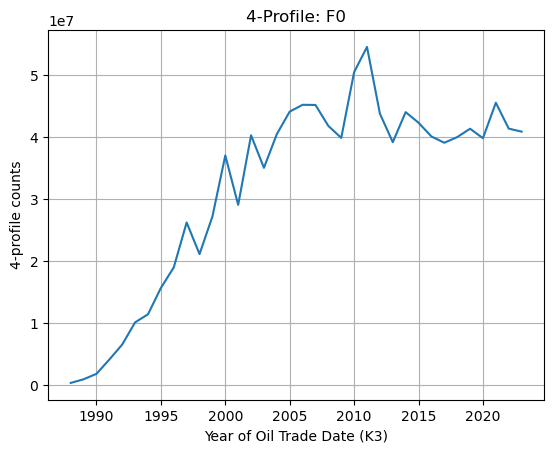

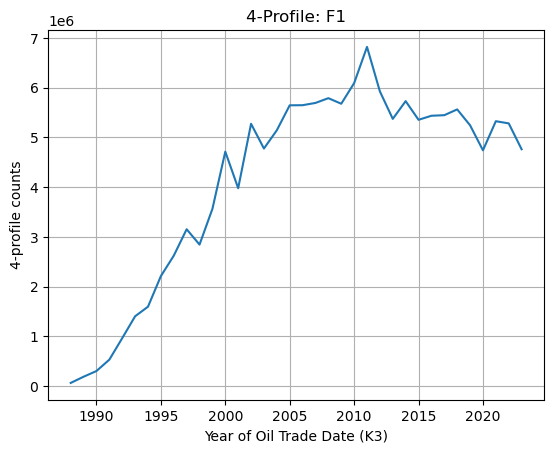

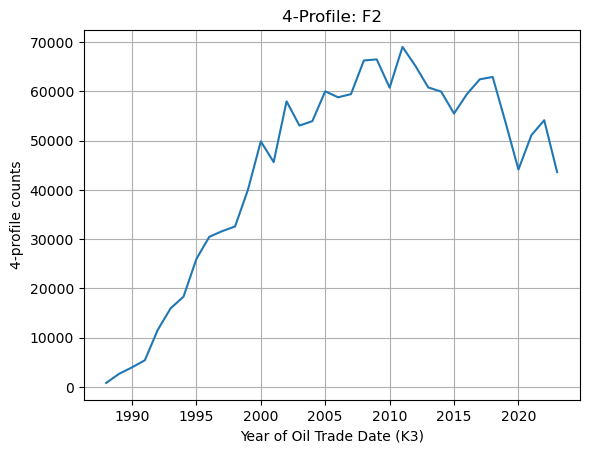

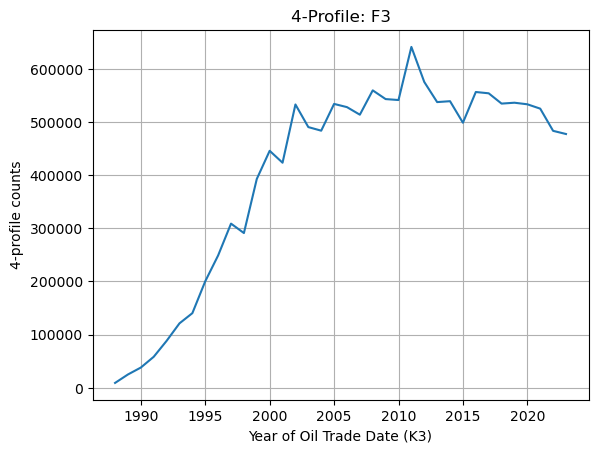

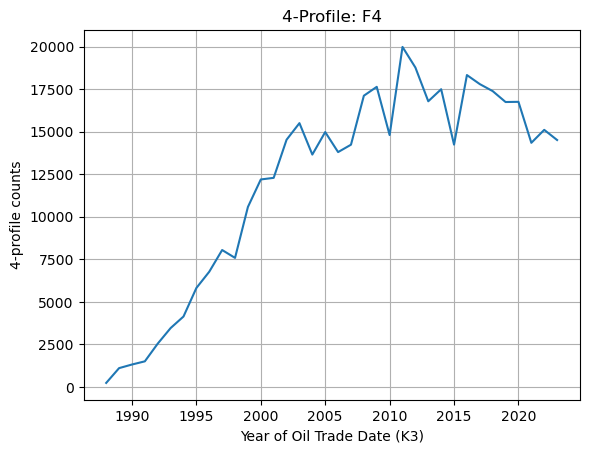

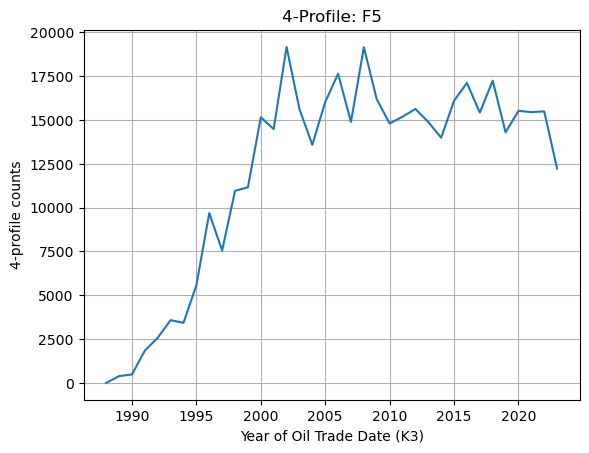

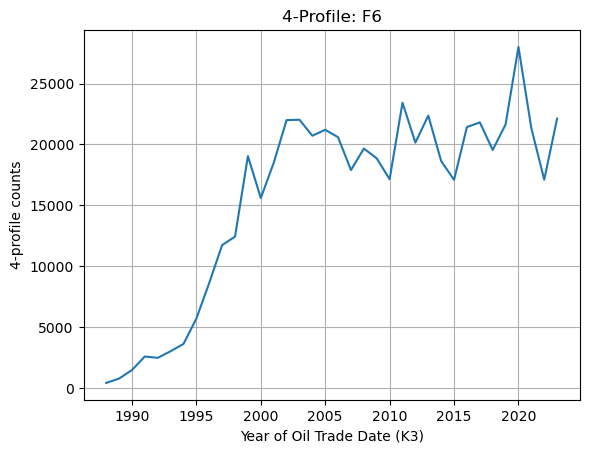

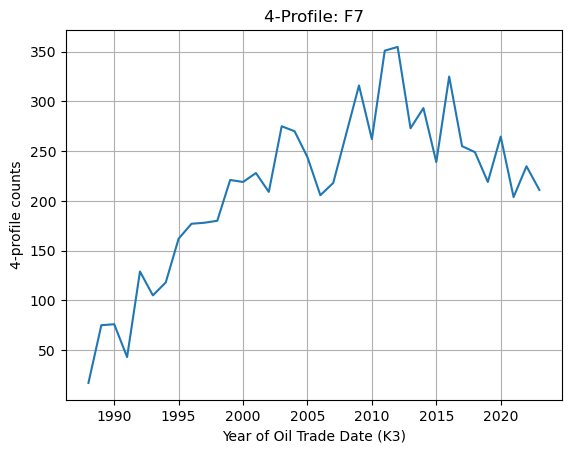

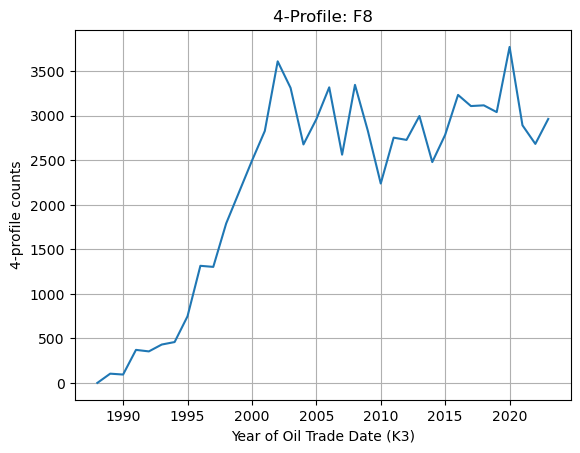

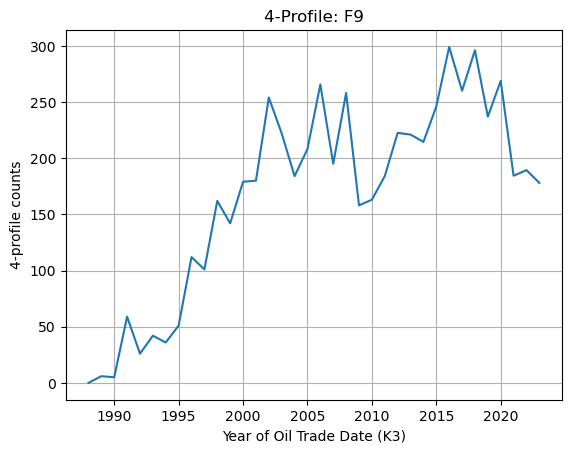

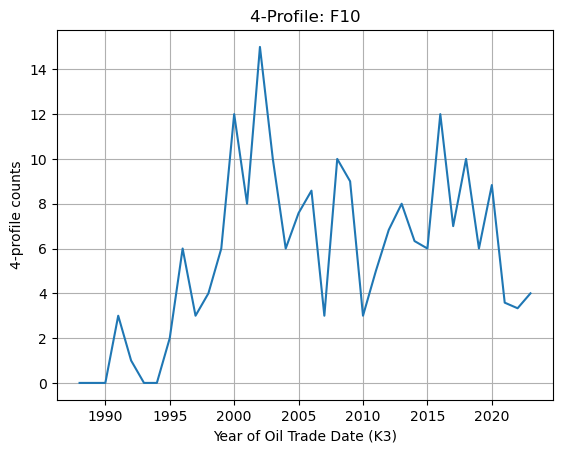

In [ ]:
years = [i for i in range(start_year, end_year)]
four_profile_dict = {year: four_profile(pruned_dict_k3[year].to_undirected()) for year in range(start_year, end_year)}

clique_types = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] # 0: anti-cliques ... 10: K4 
four_profile_data = {c: [four_profile_dict[i][c] for i in range(start_year, end_year)] for c in clique_types}

for c in clique_types:
    plt.figure() 
    plt.plot(years, four_profile_data[c], label=c)
    plt.xlabel("Year of Oil Trade Date (K3)")
    plt.ylabel("4-profile counts")
    plt.title(f"4-Profile: F{c}")
    plt.grid(True)
    plt.show()

